In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
n_customers = 500

data = {
    'Customer_ID': range(1001, 1001 + n_customers),
    'Total_Spend': np.random.uniform(10, 5000, n_customers),
    'Purchase_Frequency': np.random.randint(1, 100, n_customers),
    'Recency_Days': np.random.randint(1, 365, n_customers),
    'Return_Rate': np.random.uniform(0, 0.3, n_customers),
}

for i in range(1, 18):
    data[f'Category_{i}_Spend'] = np.random.uniform(0, 500, n_customers)

df = pd.DataFrame(data)

X = df.drop(columns=['Customer_ID'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Dataset successfully generated and PCA applied!")
print("Data Shape after PCA:", X_pca.shape)

Dataset successfully generated and PCA applied!
Data Shape after PCA: (500, 3)


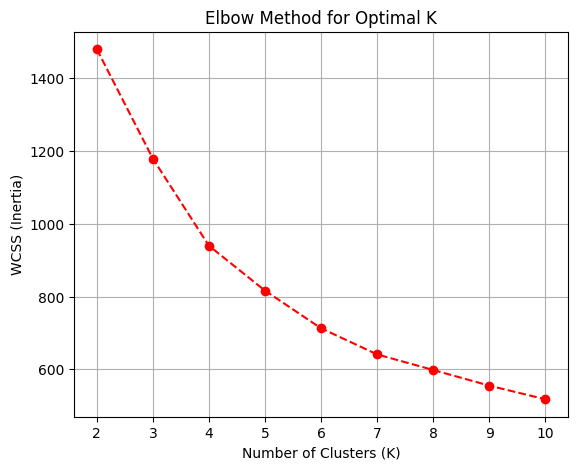

In [6]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(14, 5))

# A. Elbow Method Plot
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', color='red', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

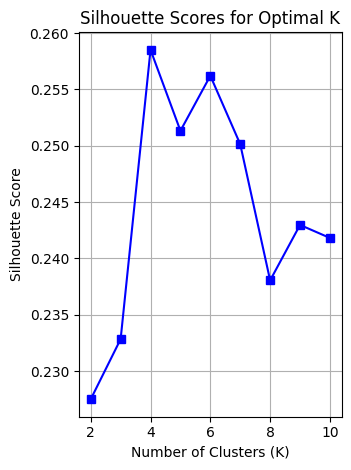

2. Mathematical Proof Plots generated. Choosing K = 3 based on results.


In [7]:
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='blue', linestyle='-')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Based on calculations, we assume optimal K = 3 or 4
optimal_k = 3
print(f"2. Mathematical Proof Plots generated. Choosing K = {optimal_k} based on results.")

In [9]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca['Cluster'] = final_kmeans.fit_predict(X_pca)
df['Cluster'] = df_pca['Cluster']

In [10]:
fig = px.scatter_3d(
    df_pca, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title="3D Customer Clusters Visualization (PCA Space)",
    labels={'Cluster': 'Customer Group'}
)
fig.show()

In [11]:
print("\n=== BUSINESS PERSONA ANALYSIS ===")
analysis = df.groupby('Cluster')[['Total_Spend', 'Purchase_Frequency', 'Recency_Days']].mean()

def get_persona_name(cluster_id):
    if cluster_id == 0:
        return "The Bargain Hunters (Low spend, high recency)"
    elif cluster_id == 1:
        return "The Loyal Enthusiasts (High spend, highly frequent)"
    else:
        return "The Seasonal Whales (High average spend, low frequency)"

analysis['Business Persona'] = [get_persona_name(i) for i in analysis.index]
print(analysis)



=== BUSINESS PERSONA ANALYSIS ===
         Total_Spend  Purchase_Frequency  Recency_Days  \
Cluster                                                  
0        2635.360221           42.309091    201.678788   
1        2918.455340           53.494318    166.607955   
2        1889.489910           49.748428    179.245283   

                                          Business Persona  
Cluster                                                     
0            The Bargain Hunters (Low spend, high recency)  
1        The Loyal Enthusiasts (High spend, highly freq...  
2        The Seasonal Whales (High average spend, low f...  
